In [3]:
%pip install -q langgraph langchain langchain-openai


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: /anaconda/envs/azureml_py310_sdkv2/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


# 랭그래프 

checked

In [4]:
from dotenv import load_dotenv
import os
load_dotenv('env')
AZURE_OPENAI_API_KEY = os.getenv('AZURE_OPENAI_API_KEY')
END_POINT=os.getenv('END_POINT')
MODEL_NAME=os.getenv('MODEL_NAME')
LANGSMITH_API_KEY=os.getenv('LANGSMITH_API_KEY')

AZURE_OPENAI_EMB_API_KEY = os.getenv('AZURE_OPENAI_EMB_API_KEY')
EMB_END_POINT=os.getenv('EMB_END_POINT')
EMB_MODEL_NAME=os.getenv('EMB_MODEL_NAME')

os.environ['LANGCHAIN_TRACING_V2'] = 'false'
os.environ['LANGCHAIN_PROJECT'] = 'LANG-1'

## 랭그래프 기본

In [5]:
from langgraph.graph import StateGraph, END
from typing import TypedDict, Annotated, List
import operator

# 1. 상태(State) 정의 및 그래프 초기화
class State(TypedDict):
    input: str
    result: str

graph = StateGraph(State)

# 2. 노드(Node) 함수 정의
def model_node(state: State):
   
    print("모델 노드가 실행 됐습니다!")

    # 상태에 액션 기록 추가
    return {"result": "성공!!"}

# 3. 노드를 그래프로 추가
graph.add_node("model", model_node)

# 4. 엣지(Edge) 정의
graph.set_entry_point("model")
graph.add_edge("model", END)

# 5. 그래프 컴파일 및 실행
app = graph.compile()

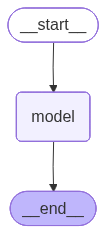

In [6]:
# plot graph
from IPython.display import Image
Image(app.get_graph().draw_mermaid_png())

In [7]:
result = app.invoke({'input': '입력', 'result' : ''})
print(result)

모델 노드가 실행 됐습니다!
{'input': '입력', 'result': '성공!!'}


In [8]:
for st in app.stream({'input': '입력', 'result' : ''}):
    print(st)

모델 노드가 실행 됐습니다!
{'model': {'result': '성공!!'}}


## 조건부 엣지가 있는 그래프

In [9]:
from langgraph.graph import StateGraph, END
from typing import TypedDict, Annotated, List
import operator, random

# 1) 상태(State)
class State(TypedDict):
    input: str
    all_actions: Annotated[List[str], operator.add] #<-- 리듀서: 노드에서 값을 반환할 때 하는 동작

# 2) 노드(Node)
def model_node(state: State):

    print("[model] 모델이 아무것도 안했습니다!")

    return {"all_actions": ["model_decision"]}

def tool_node(state: State):

    print("[tools] 뭔가 대단한 걸 했습니다!")

    return {"all_actions": ["tool_action"]}

# 3) 조건부 엣지: 랜덤으로 바로 END 또는 tools 거쳐 END
def random_route(state: State) -> str:
    route = random.choice(["end_direct", "via_tools"])
    print(f"[route] 랜덤 결정: {route}")
    return route

# 4) 그래프 구성
graph = StateGraph(State)
graph.add_node("model", model_node)
graph.add_node("tools", tool_node)

graph.set_entry_point("model")

graph.add_conditional_edges(
    "model",
    random_route,
    {
        "end_direct": END,
        "via_tools": "tools"
    }
)

# tools → END
graph.add_edge("tools", END)

# 5) 컴파일
app = graph.compile()

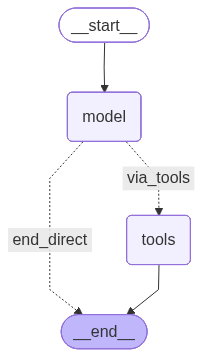

In [10]:
Image(app.get_graph().draw_mermaid_png())

In [11]:
result = app.invoke({"input": "hello", "all_actions": []})
print(result)

[model] 모델이 아무것도 안했습니다!
[route] 랜덤 결정: via_tools
[tools] 뭔가 대단한 걸 했습니다!
{'input': 'hello', 'all_actions': ['model_decision', 'tool_action']}


## 반복이 있는 그래프

In [15]:
from langgraph.graph import StateGraph, END
from typing import TypedDict, Annotated, List
import operator, random

# 1) 상태(State)
class State(TypedDict):
    input: str
    iter: int          # 반복 횟수
    all_actions: Annotated[List[str], operator.add]   #<-- 리듀서: 노드에서 값을 반환할 때 하는 동작

# 2) 노드(Node)
def model_node(state: State):

    # cur_iter = state.get("iter", 0) + 1
    iter_up = state['iter'] + 1
    print(f"[model] 모델 분기 고민 중... (iter={iter_up})")

    # 액션 로그에 기록
    return {
        "iter": iter_up,
        "all_actions": [f"model_{iter_up}"]
    }

def tool_node(state: State):
    print(f"[tools] 뭔가 대단한 걸 했습니다!")
    return {"all_actions": [f"tool_{state['iter']}"]}

# 3) 조건부 엣지
def should_continue(state: State) -> str:
    if state["iter"] >= 4:
        print("반복이 지정된 횟수를 초과했으므로 종료합니다.")
        return "end"

    return "continue"

# 4) 그래프 구성
graph = StateGraph(State)
graph.add_node("model", model_node)
graph.add_node("tools", tool_node)

graph.set_entry_point("model")
graph.add_edge("tools", "model")

graph.add_conditional_edges(
    "model",
    should_continue,
    {
        "continue": "tools", #should_continue함수의 return이 continue이면 tool로 
        "end": END           #should_continue함수의 return이 end이면 END로
    }
)

app = graph.compile()

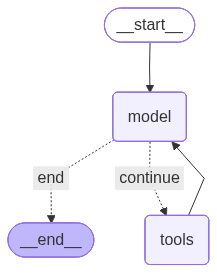

In [16]:
Image(app.get_graph().draw_mermaid_png())

In [17]:
result = app.invoke({"input": "hello", "iter": 0, "all_actions": []})
print(result)

[model] 모델 분기 고민 중... (iter=1)
[tools] 뭔가 대단한 걸 했습니다!
[model] 모델 분기 고민 중... (iter=2)
[tools] 뭔가 대단한 걸 했습니다!
[model] 모델 분기 고민 중... (iter=3)
[tools] 뭔가 대단한 걸 했습니다!
[model] 모델 분기 고민 중... (iter=4)
반복이 지정된 횟수를 초과했으므로 종료합니다.
{'input': 'hello', 'iter': 4, 'all_actions': ['model_1', 'tool_1', 'model_2', 'tool_2', 'model_3', 'tool_3', 'model_4']}


## 반복이 있는 그래프 2 - 리듀서 

이번엔 iter에 리듀서를 추가하고 삭제해봅시다. model_node를 다시 봅시다.

In [18]:
from langgraph.graph import StateGraph, END
from typing import TypedDict, Annotated, List
import operator, random

# 1) 상태(State)

# 리듀서 함수 
# 이전에 state값과 현재 갱신된 state 두 개를 받아서 합치는 방법을 결정
increment = lambda old, new : old + 1  #실행될 때마다 자동 +1

class State(TypedDict):
    input: str
    iter: Annotated[int, increment]          # Annotated를 사용하면 리듀서를 설정할 수 있습니다.
    all_actions: List[str]               #<-- 이번엔 반대로 all action에 리듀서를 제거

# 2) 노드(Node)
def model_node(state: State):

    print(f"[model] 모델 분기 고민 중... (iter={state['iter']})")
    
    return { 
        "iter": None, #<-- 아무것도 리턴하지 않아도 리듀서에 의해서 값이 1 증가
        "all_actions": [f"model_{state['iter']}"]
    }

def tool_node(state: State):
    print(f"[tools] 뭔가 대단한 걸 했습니다!")
    return {"all_actions": [f"tool_{state['iter']}"]}

# 3) 조건부 엣지
def should_continue(state: State) -> str:
    if state["iter"] >= 4:
        print("반복이 지정된 횟수를 초과했으므로 종료합니다.")
        return "end"

    return "continue"

# 4) 그래프 구성
graph = StateGraph(State)
graph.add_node("model", model_node)
graph.add_node("tools", tool_node)

graph.set_entry_point("model")
graph.add_edge("tools", "model")

graph.add_conditional_edges(
    "model",
    should_continue,
    {
        "continue": "tools",
        "end": END
    }
)

app = graph.compile()

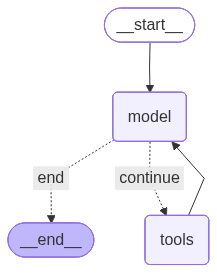

In [19]:
Image(app.get_graph().draw_mermaid_png())

all_actions에 리듀서가 없으므로 노드가 리턴한 최신 값으로 갱신됨

In [20]:
result = app.invoke({"input": "hello", "iter": 0, "all_actions": []})
print(result)

[model] 모델 분기 고민 중... (iter=1)
[tools] 뭔가 대단한 걸 했습니다!
[model] 모델 분기 고민 중... (iter=2)
[tools] 뭔가 대단한 걸 했습니다!
[model] 모델 분기 고민 중... (iter=3)
반복이 지정된 횟수를 초과했으므로 종료합니다.
{'input': 'hello', 'iter': 4, 'all_actions': ['model_3']}


## 나이별 용어 설명기 만들기

In [21]:
# pip install langchain langgraph langchain-openai python-dotenv
from typing import TypedDict, Annotated, List, Optional
import operator
from langgraph.graph import StateGraph, END
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate

from langchain_openai import AzureChatOpenAI

llm = AzureChatOpenAI(
    api_key=AZURE_OPENAI_API_KEY,
    azure_endpoint=END_POINT,  
    azure_deployment=MODEL_NAME,          
    api_version="2024-12-01-preview",
    temperature=0.2,
)

# 1) 상태 정의
class State(TypedDict):
    term: str                       # 설명할 용어 
    age: int                        # 대상 나이
    audience: Optional[str]         # 분기 결과: "kinder"|"elementary"|"teen"|"expert"
    result: Optional[str]           # 최종 설명문
    logs: Optional[str]            # 누가 수행되었는지 로그

# 2) 라우터(조건부 분기 기준 계산)
def audience_router(state: State) -> dict:
    age = state["age"]
    if age < 8:
        audience = "kinder"
    elif age <= 13:
        audience = "elementary"
    elif age <= 20:
        audience = "teen"
    else:
        audience = "expert"
    return {"audience": audience, "logs": [f"[route]"]}

# 3) 각 타깃별 프롬프트 (LLM은 동일, 톤만 바꿈)
prompt_kinder = ChatPromptTemplate.from_messages([
    ("system",
     "너는 유치원생에게 친절하고 재미있게 설명하는 선생님이야. "
     "어려운 말은 쓰지 말고, 짧고 쉽게, 비유를 꼭 하나 써줘."),
    ("user", "단어: {term}\n를 {age}살 유치원생에게 설명해줘. ")
])

prompt_elementary = ChatPromptTemplate.from_messages([
    ("system",
     "너는 초등학생에게 설명하는 선생님이야. 핵심 정의 1~2문장 + 쉬운 예시를 포함해."),
    ("user", "용어: {term}\n를 {age}살 초등학생 수준으로 설명해줘.")
])

prompt_teen = ChatPromptTemplate.from_messages([
    ("system",
     "너는 중고등학생에게 설명하는 선생님이야. "
     "정의→원리→간단한 응용 순서로 5~7문장 내로 정리해."
     "교과과정에서 어떤 부분을 더 학습하면 좋은지도 간단하게 소개해줘"),
    ("user", "용어: {term}\n를 {age}살 중고등학생 수준으로 설명해줘.")
])

prompt_expert = ChatPromptTemplate.from_messages([
    ("system",
     "너는 전문가가 전문가에게 설명하듯 기술적으로 설명해. "
     "핵심 개념, 수식/알고리즘 포인트, 실무적 고려사항을 간결히."),
    ("user", "용어: {term}\n를 전문가 수준으로 설명해줘.")
])

def explain_kinder(state: State) -> dict:
    out = (prompt_kinder | llm).invoke({"term": state["term"], "age" : state['age']})
    return {"result": out.content, "logs": ["[kinder]"]}

def explain_elementary(state: State) -> dict:
    out = (prompt_elementary | llm).invoke({"term": state["term"], "age" : state['age']})
    return {"result": out.content, "logs": ["[elementary]"]}

def explain_teen(state: State) -> dict:
    out = (prompt_teen | llm).invoke({"term": state["term"], "age" : state['age']})
    return {"result": out.content, "logs": ["[teen]"]}

def explain_expert(state: State) -> dict:
    out = (prompt_expert | llm).invoke({"term": state["term"]})
    return {"result": out.content, "logs": ["[expert]"]}

# 4) 그래프 구성 (조건부 엣지)
graph = StateGraph(State)
graph.add_node("route", audience_router)
graph.add_node("kinder", explain_kinder)
graph.add_node("elementary", explain_elementary)
graph.add_node("teen", explain_teen)
graph.add_node("expert", explain_expert)

graph.set_entry_point("route")

def route_by_age(state: State) -> str:
    return state["audience"] or "expert"

graph.add_conditional_edges("route", route_by_age, {
    "kinder": "kinder",
    "elementary": "elementary",
    "teen": "teen",
    "expert": "expert",
})

# 각 분기 종료
graph.add_edge("kinder", END)
graph.add_edge("elementary", END)
graph.add_edge("teen", END)
graph.add_edge("expert", END)

app = graph.compile()

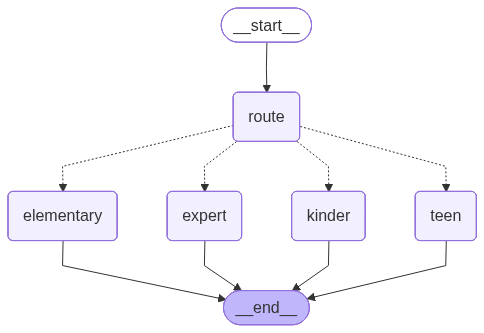

In [22]:
Image(app.get_graph().draw_mermaid_png())

In [23]:
for age in (4, 10, 16, 30):
    init_state = {"term": "인공지능이 뭐야?", "age": age, "audience": None, "result": None, "logs": None}
    out = app.invoke(init_state)
    print("\n===========\n age:", age, "audience:", out["audience"], "===")
    print(out["result"])
    print("LOGS:", out["logs"])


 age: 4 audience: kinder ===
인공지능은 똑똑한 로봇 친구야! 마치 장난감 자동차가 스스로 움직이는 것처럼, 인공지능은 컴퓨터가 생각하고 배우는 거야. 그래서 우리가 말하면 알아듣고 도와줄 수 있어!
LOGS: ['[kinder]']

 age: 10 audience: elementary ===
인공지능은 컴퓨터가 사람처럼 똑똑하게 생각하고 배우는 기술이에요. 예를 들어, 스마트폰이 우리가 말하는 걸 알아듣고 답해 주는 것도 인공지능 덕분이에요.
LOGS: ['[elementary]']

 age: 16 audience: teen ===
인공지능(AI)은 컴퓨터가 사람처럼 생각하고 배우도록 만드는 기술이야. 원리는 컴퓨터에 많은 데이터를 주고, 그 데이터를 바탕으로 스스로 규칙을 찾아 문제를 해결하게 하는 거야. 예를 들어, AI는 사진 속 동물을 구분하거나, 음성으로 명령을 이해할 수 있어. 간단한 응용으로는 스마트폰의 음성 비서나 추천 시스템이 있어. 더 깊이 배우고 싶다면 중학교나 고등학교에서 배우는 '컴퓨터 과학'과 '정보 기술' 과목을 공부하면 좋아. 특히, 알고리즘과 프로그래밍을 배우면 AI 원리를 더 잘 이해할 수 있어.
LOGS: ['[teen]']

 age: 30 audience: expert ===
인공지능(AI, Artificial Intelligence)은 인간의 인지능력, 학습, 추론, 문제 해결, 자연어 처리 등을 컴퓨터 시스템이 모방하도록 설계된 알고리즘 및 시스템의 총체를 의미한다. 

핵심 개념:
- 지능적 행위의 자동화: 인지(Perception), 추론(Reasoning), 학습(Learning), 계획(Planning), 자연어 이해(NLU), 의사결정(Decision Making) 등.
- 기계학습(ML): 데이터로부터 패턴을 학습해 일반화하는 알고리즘. 지도학습, 비지도학습, 강화학습으로 구분.
- 심층학습(Deep Learning): 다층 신경망을 이용한 비선형 함수 근사, 대규모 데이터와 연산